In [2]:
import pandas as pd
import matplotlib.pyplot as plt


<h2>Data Loading</h2>

Here, I loaded the 3 raw datasets that we will be using. I has also loaded the lookup tables, though they are not visible yet and will be made clearer in the data cleaning process. Below I have displayed the top 5 rows of each of the raw datasets. 

In [3]:
#Importing music micro dataset, without id columns value pairs.
file_path = 'raw_data/musicmicro/listening_data.txt'

music_micro_raw = pd.read_csv(
    file_path,
    sep="\t",
    header=0,
    index_col=False)

music_micro_raw.head()

,twitter-id,user-id,month,weekday,longitude,latitude,country-id,city-id,artist-id,track-id
0,134243699369590784,74717431,11,2,-50.531223,-18.453224,0,0,450514,7748381
1,134243700380401664,127821914,11,2,106.834450,-6.232960,1,1,202085,3529910
2,134243869201154048,174194590,11,2,-0.142822,51.520740,2,2,330061,5762915
3,134244034020524032,141847381,11,2,106.752390,-6.576483,1,3,404350,6987845
4,134244371557122048,87215499,11,2,-73.989890,40.738976,3,4,227460,4082536


In [4]:
#Importing raw mental health dataset.
mental_health_data_raw = pd.read_csv('raw_data/Mental Health Dataset.csv')
mental_health_data_raw.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [5]:

# load lines
with open("raw_data/songNames.txt", "r", encoding="utf-8") as f:
    cal_500_raw = pd.DataFrame({"artist_track": [line.strip() for line in f if line.strip()]})

# split artist + track
cal_500_raw[["artist", "track"]] = cal_500_raw["artist_track"].str.split("-", n=1, expand=True)

# clean text
def clean(s):
    return (
        s.str.lower()
         .str.replace("_", "", regex=False)
         .str.replace(r"[^\w\s]", "", regex=True)
         .str.replace(r"\s+", " ", regex=True)
         .str.strip()
    )

cal_500_raw["artist"] = clean(cal_500_raw["artist"])
cal_500_raw["track"] = clean(cal_500_raw["track"])

# optional: drop original column
cal_500_raw = cal_500_raw.drop(columns="artist_track")

cal_500_raw.head()

,artist,track
0,10cc,foryouandi
1,2pac,trapped
2,5thdimension,onelessbelltoanswer
3,atribecalledquest,bonitaapplebum
4,aaronneville,tellitlikeitis


In [6]:
#Added vectorized tags to the cal_500 dataset.
hard = pd.read_csv("raw_data/hardAnnotations.txt", header=None)  # add the full path if needed
hard.columns = pd.read_csv("raw_data/vocab.txt", header=None)[0].tolist()
music_tagging = pd.concat([cal_500_raw, hard], axis=1)
music_tagging.head()

,artist,track,Emotion-Angry_/_Agressive,NOT-Emotion-Angry_/_Agressive,Emotion-Arousing_/_Awakening,NOT-Emotion-Arousing_/_Awakening,Emotion-Bizarre_/_Weird,NOT-Emotion-Bizarre_/_Weird,Emotion-Calming_/_Soothing,NOT-Emotion-Calming_/_Soothing,...,Genre-Best-World,Instrument_-_Acoustic_Guitar-Solo,Instrument_-_Electric_Guitar_(clean)-Solo,Instrument_-_Electric_Guitar_(distorted)-Solo,Instrument_-_Female_Lead_Vocals-Solo,Instrument_-_Harmonica-Solo,Instrument_-_Male_Lead_Vocals-Solo,Instrument_-_Piano-Solo,Instrument_-_Saxophone-Solo,Instrument_-_Trumpet-Solo
0,10cc,foryouandi,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,1,0,0,0
1,2pac,trapped,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,5thdimension,onelessbelltoanswer,0,0,0,0,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
3,atribecalledquest,bonitaapplebum,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,aaronneville,tellitlikeitis,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


<h2>Data Cleaning</h2>

Adding track and artist names to music micro:

In [7]:
track_mapping = pd.read_csv('raw_data/musicmicro/track_mapping.txt', sep="\t")
artist_mapping = pd.read_csv('raw_data/musicmicro/artist_mapping.txt', sep="\t")

artist_mapping['artist'] = artist_mapping['artist'].str.lower().str.replace(' ', '')
track_mapping['track'] = track_mapping['track'].str.lower().str.replace(' ', '')


In [8]:
g = pd.merge(music_micro_raw, artist_mapping, on='artist-id', how='inner')
music_micro_ta = pd.merge(g, track_mapping, on='track-id', how='inner')
music_micro_ta

,twitter-id,user-id,month,weekday,longitude,latitude,country-id,city-id,artist-id,track-id,artist,track
0,134243699369590784,74717431,11,2,-50.531223,-18.453224,0,0,450514,7748381,tihuana,naparededoquintal
1,134243700380401664,127821914,11,2,106.834450,-6.232960,1,1,202085,3529910,jamesmorrison,yougivemesomething
2,134243869201154048,174194590,11,2,-0.142822,51.520740,2,2,330061,5762915,petshopboys,westendgirls
3,134244034020524032,141847381,11,2,106.752390,-6.576483,1,3,404350,6987845,suede,everythingwillflow
4,134244371557122048,87215499,11,2,-73.989890,40.738976,3,4,227460,4082536,kaskade,ice
...,...,...,...,...,...,...,...,...,...,...,...,...
452751,250847226383978496,70563820,9,2,110.340640,-7.802276,1,1907,301871,9530975,natashabedingfield,betweentheraindrops
452752,250847725116071936,370457976,9,2,107.626190,-6.905580,1,114,215116,3848019,johnmayer,somethinglikeolivia
452753,250849073052143616,134108604,9,2,-76.718850,39.955963,3,548,283679,5020296,michaelfranti&spearhead,sayhey
452754,250849250706092032,219099036,9,2,-111.669560,40.220425,3,5091,68747,1224442,carteldesanta,traficandorimas


Merge and create final Music dataset 

In [9]:
matched = pd.merge(music_micro_ta, music_tagging, on=['artist', 'track'], how='inner')
matched

,twitter-id,user-id,month,weekday,longitude,latitude,country-id,city-id,artist-id,track-id,...,Genre-Best-World,Instrument_-_Acoustic_Guitar-Solo,Instrument_-_Electric_Guitar_(clean)-Solo,Instrument_-_Electric_Guitar_(distorted)-Solo,Instrument_-_Female_Lead_Vocals-Solo,Instrument_-_Harmonica-Solo,Instrument_-_Male_Lead_Vocals-Solo,Instrument_-_Piano-Solo,Instrument_-_Saxophone-Solo,Instrument_-_Trumpet-Solo
0,134266061230047232,314649657,11,2,-51.177275,-29.915337,0,86,343878,5986620,...,0,0,0,0,0,0,0,0,0,0
1,134312266639212544,329400087,11,2,-45.917521,-23.061418,0,306,78492,1403960,...,0,0,0,0,0,0,0,0,0,1
2,134339142418042880,105875448,11,2,-43.447310,-22.916032,0,50,393462,6800302,...,0,0,0,0,0,0,0,0,0,0
3,134350511678832641,108600330,11,2,-76.639496,39.304510,3,297,414087,7130125,...,0,0,0,0,0,0,0,0,0,0
4,134357350260809730,39820216,11,2,4.904054,52.354750,14,98,393462,6800302,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2692,250395709398986752,26432623,9,1,-122.912750,49.199432,5,387,468091,8029759,...,0,1,0,0,0,0,0,0,0,0
2693,250533563949277185,325338295,9,1,106.826795,-6.168961,1,17,477249,8182052,...,0,0,1,1,0,0,0,0,0,0
2694,250627160333770754,49146752,9,1,-46.595545,-23.682814,0,5,51218,902128,...,0,0,0,0,0,0,0,0,0,0
2695,250637024867008512,423348268,9,1,35.243322,38.963745,9,33,66022,1172796,...,0,0,0,0,0,0,0,0,0,0


Giving categorical features in the mental health dataset numerical values, and adding a column for seasons:

In [11]:
mental_health_data_raw.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


First, we check to see which columns contain NaN values, and fill those in with 'Unknown', because some of our tests won't work if NaN values are present. We see below the only feature containing NaN values is `self_employed`, so we will that in.

In [13]:
survey_cols = mental_health_data_raw.columns
mental_health_data_raw[survey_cols].isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [14]:
mental_health_data_raw['self_employed'] = mental_health_data_raw['self_employed'].fillna('Unknown')
mental_health_data_raw.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


Next, we will take all the categories containing "Yes" or "No" questions, and fill in Yes's with 1, and No's with 0, as well as Maybe's with 0.5

In [20]:
yes_no = ['family_history', 'treatment', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview']

yes_no_transition = lambda s: 1 if s == 'Yes' else 0 if s == 'No' else 0.5

mental_health_data_clean = mental_health_data_raw.copy()

for cat in yes_no:
    mental_health_data_clean[cat] = mental_health_data_clean[cat].apply(yes_no_transition)

mental_health_data_clean.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,No
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.5,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,Yes


Next, we'll fill in `Days_Indoors`, `Mood_Swings`, and `care_options` with representative numerical values.

In [24]:
days_indoors_map = lambda s: 0 if s == 'Go out Every day' else 1 if s == '1-14 days' else 2 if s == '15-30 days' else 3 if s == '31-60 days' else 4
mental_health_data_clean['Days_Indoors'] = mental_health_data_clean['Days_Indoors'].apply(days_indoors_map)

mood_swings_map = lambda s: 0 if s == 'Low' else 1 if s == 'Medium' else 2
mental_health_data_clean['Mood_Swings'] = mental_health_data_clean['Mood_Swings'].apply(mood_swings_map)

care_options_map = lambda s: 0 if s == 'No' else 1 if s == 'Yes' else 0.5
mental_health_data_clean['care_options'] = mental_health_data_clean['care_options'].apply(care_options_map)

mental_health_data_clean.head()


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,0.5
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,0.0
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,1.0
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.5,1.0
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,1.0


Finally, we'll convert the timestamp column into indvidual seasons because we'll be testing which music trends across different seasons

In [ ]:
mental_health_data_clean['Timestamp'] = pd.to_datetime(mental_health_data_clean['Timestamp'])
mental_health_data_clean['Month'] = mental_health_data_clean['Timestamp'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

mental_health_data_clean['Season'] = mental_health_data_clean['Month'].apply(get_season)
mental_health_data_clean.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Month,Season
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,0.5,8,Summer
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,0.0,8,Summer
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,1.0,8,Summer
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.5,1.0,8,Summer
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,1.0,8,Summer


<h2>Calculating Music Valence:</h2>

**Music valence** describes the emotional positivity or negativity expressed by a piece of music. It represents how *happy, cheerful, or uplifting* a song feels versus how *sad, dark, or melancholic* it feels. Valence is typically measured on a continuous scale (often 0–1), where higher values indicate more positive emotional content and lower values indicate more negative emotional content.

In [9]:
music_df = matched.copy()
positive = [
    "Emotion-Happy",
    "Emotion-Cheerful_/_Festive",
    "Emotion-Positive_/_Optimistic",
    "Emotion-Pleasant_/_Comfortable",
    "Emotion-Loving_/_Romantic",
    "Emotion-Carefree_/_Lighthearted",
]

negative = [
    "Emotion-Sad",
    "Emotion-Angry_/_Agressive",
    "Emotion-Bizarre_/_Weird"
]

music_df["valence"] = (
    music_df[positive].sum(axis=1) - music_df[negative].sum(axis=1)
) / (music_df[positive].sum(axis=1) + music_df[negative].sum(axis=1) + 1e-6)



<h3> A Descriptive Plots on Music Valence:  </h3>

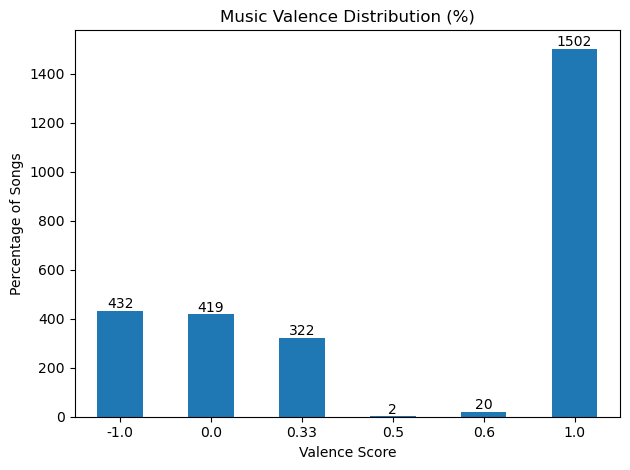

In [10]:
valence_pct = music_df["valence"].round(2).value_counts(normalize=True).sort_index()

(valence_pct * 100).plot(kind="bar")

valence_counts = music_df["valence"].round(2).value_counts().sort_index()

ax = valence_counts.plot(kind="bar")

plt.title("Distribution of Music Valence")
plt.xlabel("Valence Score")
plt.ylabel("Number of Songs")

# add count labels
for i, v in enumerate(valence_counts):
    ax.text(i, v + 10, str(v), ha='center')


plt.title("Music Valence Distribution (%)")
plt.xlabel("Valence Score")
plt.ylabel("Percentage of Songs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

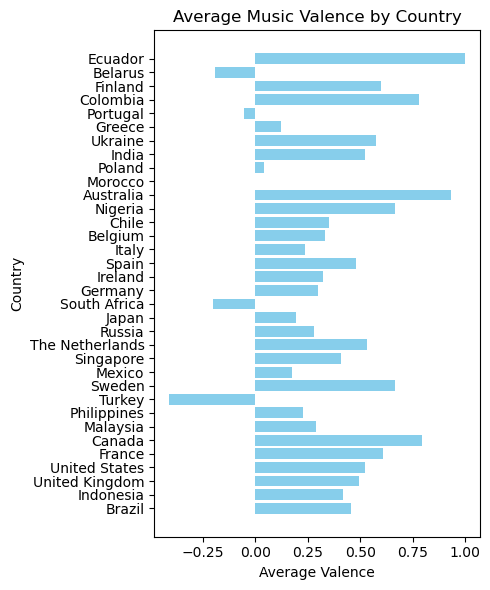

In [11]:
country_stats = (
    music_df.groupby("country-id")["valence"]
    .agg(["mean", "count"])
    .reset_index()
)
#Filtered out contries with less than 5 songs to ensure more reliable average valence scores.
country_stats = country_stats[country_stats["count"] >= 5]

country_mapping = pd.read_csv('raw_data/country_mapping.csv')
country_stats = pd.merge(country_stats, country_mapping, on='country-id', how='inner')
 
plt.figure(figsize=(5,6))
plt.barh(country_stats['country'], country_stats['mean'], color='skyblue')

plt.xlabel("Average Valence")
plt.ylabel("Country")
plt.title("Average Music Valence by Country")

plt.tight_layout()
plt.show()


## Calculating Composite Mental Health Score with PCA

Since we converted the mental health survey responses to numerical value, we can then use PCA below to convert these 12 factors into a composite score. Here, a higher `composite_mh_score` represents poorer mental health for an individual.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

survey_features = ['family_history', 'treatment', 'Growing_Stress', 'Changes_Habits', 
    'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 
    'Work_Interest', 'Social_Weakness', 'mental_health_interview', 
    'care_options', 'Days_Indoors']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(mental_health_data_clean[survey_features])

pca = PCA(n_components=1)

mental_health_data_clean['composite_mh_score'] = pca.fit_transform(scaled_data)

Explained Variance: 15.20%


In [31]:
mental_health_data_clean.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Month,Season,composite_mh_score
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,0.5,8,Summer,0.278557
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,0.0,8,Summer,0.952012
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,1.0,8,Summer,2.013382
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.5,1.0,8,Summer,1.736900
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,4,1.0,0.0,1.0,2,0,0.0,1.0,0.0,1.0,8,Summer,2.013382


#### Plots for Mental Health

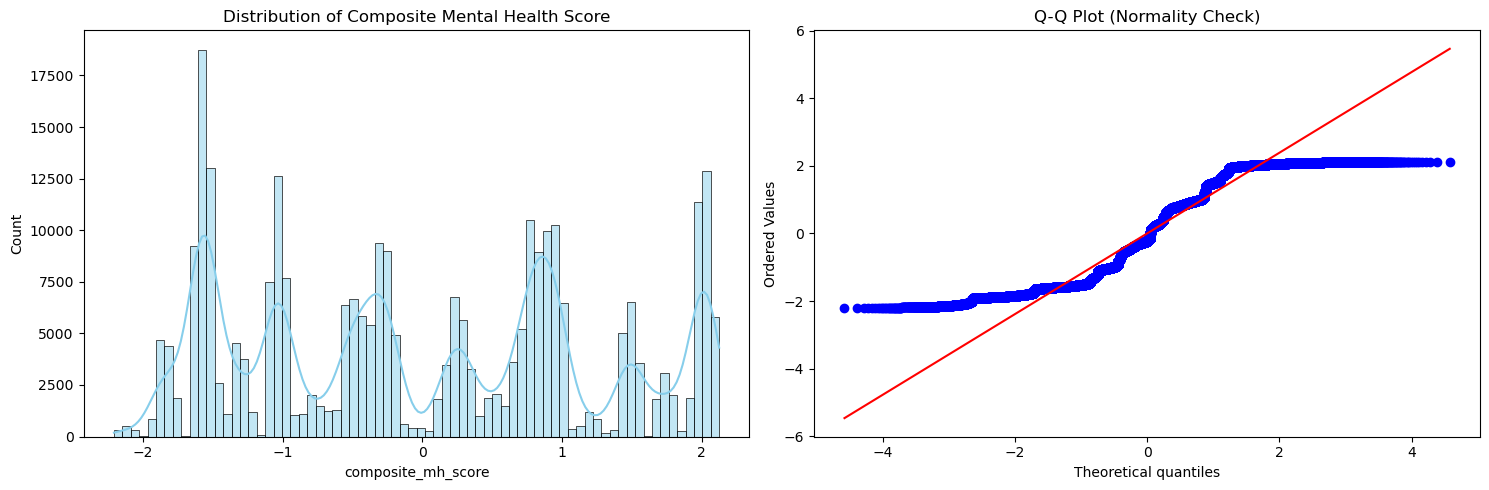

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(mental_health_data_clean['composite_mh_score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Composite Mental Health Score')

# Q-Q Plot
stats.probplot(mental_health_data_clean['composite_mh_score'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
plt.tight_layout()
plt.show()

/var/folders/9k/jmm192cd4qgfwgw8kn2fwkfm0000gn/T/ipykernel_77864/70079460.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=season_order, patch_artist=True,


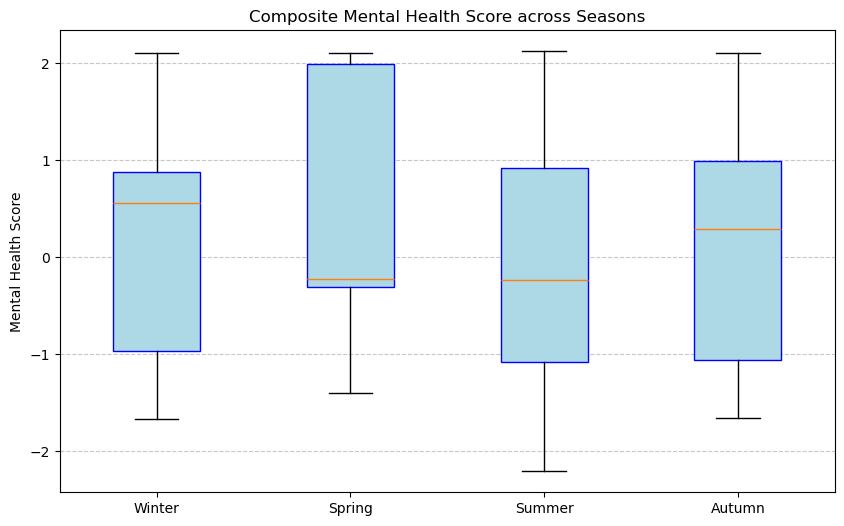

In [34]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
data_to_plot = [mental_health_data_clean[mental_health_data_clean['Season'] == s]['composite_mh_score'] for s in season_order]

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=season_order, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='blue'))

plt.title('Composite Mental Health Score across Seasons')
plt.ylabel('Mental Health Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()